# Stationarity

<img src="cover.png" style="width: 40%; display: block; margin: auto;">

## Introduction

- Previously, we learned that time series is data that is measured at equally-spaced intervals.
- We also learned that time series data are very important and widely used in many different applicatios.
- Now we'll dig deeper by discussing an important concept called **stationarity**.
- Having a firm grasp of this will lay the foundation necessary to understand more advanced modeling strategies that we'll introduce later.

In this lecture we will cover
- Definition of stationarity and examples of common stationary and nonstationary time series.
- How to detect stationarity.
- The most common ways to transform nonstationary time series into stationary ones.

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
np.random.seed(0) # Reproducibility

---

## Stationary Time Series

### Why is stationarity important?

- Stationarity is a fundamental assumption in many time series forecasting models.
- Without it many basic time series models would break.
- Transformations can be applied to convert a nonstationary time series to a stationary one.
- There are advanced time series models that can handle nonstationary data (beyond the scope of this lecture).

### What is stationarity?

- 💡 Intuition: a time series is stationary when there are no changes in the underlying system that generates it.
- In the following, we define:
    - Strict stationarity.
    - Weak stationarity.
    - Things to check in practice.

#### Strict stationarity

- A stochastic process $X(t): t \in \mathcal{T}$ is called strictly stationary if, for all $t_1, t_2, \dots, t_n \in \mathcal{T}$ and $h$ such that $t_1+h, t_2+h, \dots, t_n+h \in \mathcal{T}$, it holds that

$$\big(X(t_1),X(t_2), \dots, X(t_n)\big) \stackrel{\text{D}}{=} \big(X(t_1+h),X(t_2+h), \dots, X(t_n+h)\big)$$

- where $\stackrel{\text{D}}{=}$ indicates that the distributions are equal.
- In plain words, the joint distribution of any set of observations in the series remains the same regardless of the time at which the observations are taken.

- Strict stationarity is very difficult to verify, especially from a limited amount of data.
- For this reason, one checks the *Weak stationarity*.

#### Weak stationarity

- A time series $X$ is weakly stationary if:

  1. The mean is constant over time $\mathbb{E}[X(t)] = m, \;\; \forall t \in \mathcal{T}$
  2. The variance is finite $\mathbb{E}[X(t)^2] < \infty, \;\; \forall t \in \mathcal{T}$
  3. The covariance of $X(t)$ and $X(t+h)$ depends only on $h$, i.e., is shift-invariance in time.

- Strict stationarity + condition 2 $\implies$ weak stationarity

#### Things to check in practice.

1. Constant mean (no trend).
2. Constant variance (no heteroskedasticity).
3. Constant autocorrelation structure.
4. No periodic component (✋ careful here)

- Mean, variance, and periodic component (aka seasonality) should be familiar from the previous lecture.
- Autocorrelation may not be.
- Let's start with a simple example of a stationary time series.

- Let's create an utility function to make plots.

In [2]:
def run_sequence_plot(x, y, title, xlabel="Time", ylabel="Values", ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1, figsize=(10, 3.5))
    ax.plot(x, y, 'k-')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    return ax

- First, we create a variable `time` that defines equally-spaced time intervals.
- Then we'll sample values from a Normal distribution with a mean of 0 and a standard deviation of 1.
- Essentially we're creating white noise, which is a stationary time series as it exhibits all the properties required of a stationary time series.

In [3]:
T = 200
time = np.arange(T)
stationary = np.random.normal(loc=0, scale=1.0, size=T)

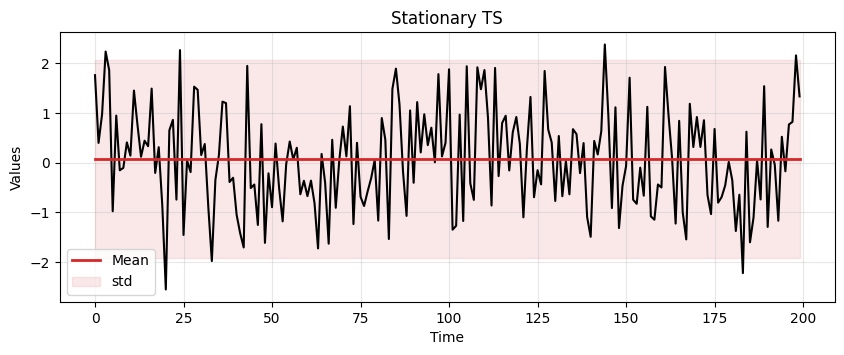

In [7]:
ax = run_sequence_plot(time, stationary, title="Stationary TS")
ax.plot(time, np.ones_like(time)*np.mean(stationary), linewidth=2, color='tab:red', label='Mean');
ax.fill_between(time, np.ones_like(time)*(stationary.mean()-1.95*stationary.std()),
                 np.ones_like(time)*(stationary.mean()+1.95*stationary.std()),
                 color='tab:red', alpha=0.1, label='std')
plt.legend();

- We can easily check that the white noise has constant mean, constant variance, and no periodicity.
- What about the autocorrelation?

**Example: constant autocorrelation**

- Time series of daily temperature in a specific location over a year.
- If this location has a very stable climate, the day-to-day changes in temperature might be minimal and consistent throughout the year.
- Then, the autocorrelation would be relatively constant.
- E.g., the correlation between today's temperature and tomorrow's temperature is roughly the same as the correlation between the temperature 30 days ago and 29 days ago.

**Example: time-varying autocorrelation**

- Time series representing the daily stock prices of a particular company.
- Stock prices can be influenced by market trends, company performance, economic indicators, world events, etc...
- Here, the autocorrelation might be time-dependent.
- E.g., during a period of market stability, the stock prices might show a consistent pattern over time (e.g., a steady increase).
- However, during a market upheaval or a significant company event (like a product launch or a scandal), the pattern could change dramatically.

#### Constant vs non-constant autocorrelation

- Consider two time series $X$ and $Y$.
    - In $X$ the autocorrelation is constant over time.
    - In $Y$ the autocorrelation changes after 100 steps.
- We will use an AR process for this example (more details on AR later on).


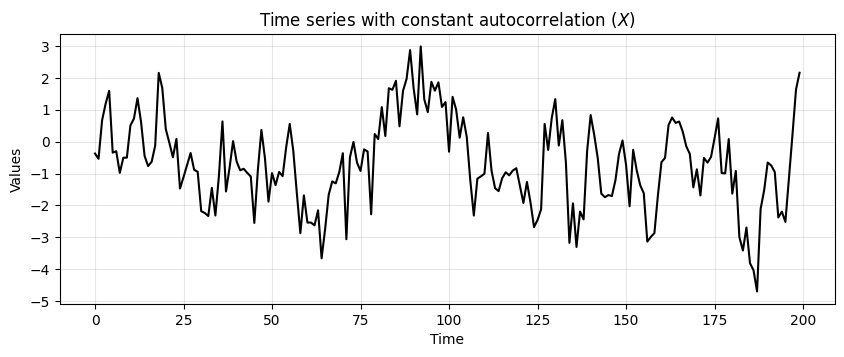

In [5]:
ar1 = np.array([1, -0.8])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
constant_autocorr_ts = AR_object1.generate_sample(nsample=200)

run_sequence_plot(time, constant_autocorr_ts,
                  title="Time series with constant autocorrelation ($X$)");

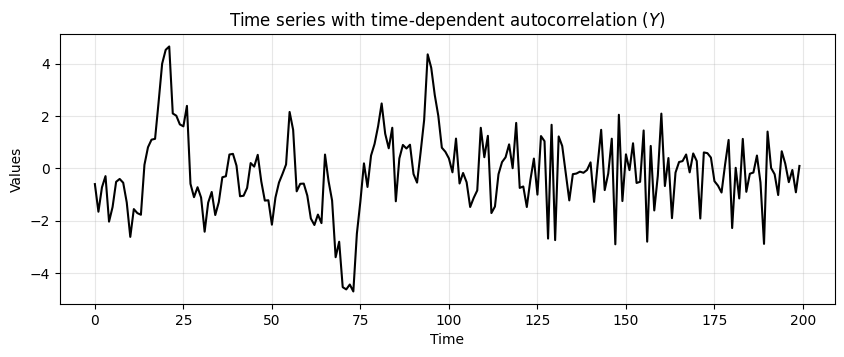

In [6]:
ar2 = np.array([1, -0.9])
AR_object2 = ArmaProcess(ar2, ma1)
ar3 = np.array([1, 0.3])
AR_object3 = ArmaProcess(ar3, ma1)

time_dependent_autocorr_ts_1 = AR_object2.generate_sample(nsample=100)
time_dependent_autocorr_ts_2 = AR_object3.generate_sample(nsample=100)
time_dependent_autocorr_ts = np.concatenate([time_dependent_autocorr_ts_1,
                                             time_dependent_autocorr_ts_2])

run_sequence_plot(time, time_dependent_autocorr_ts,
                  title="Time series with time-dependent autocorrelation ($Y$)");

- Notice how the first half of $Y$ shows a *stronger autocorrelation*.
- Each value is heavily influenced by its immediate predecessor, leading to a smooth and predictable pattern.


- The second part is characterized by a *weaker autocorrelation*.
- The time series is more erratic and less influenced by its past values.

### Common stationary and nonstationary time series

- If the analytic expression of the time series is known, it is possible to check the conditions for stationarity.
- In practice, the process generating the time series might be unknown and we'll need other tools to check stationarity.
- Starting the analysis by looking at the `run_sequence_plot` is an excellent starting point.

#### White noise

- We already looked at this time series and conclude that mean and variance are constant and there is no seasonal component.
- In addition, since the value of each time step is drawn independently, there is no correlation.

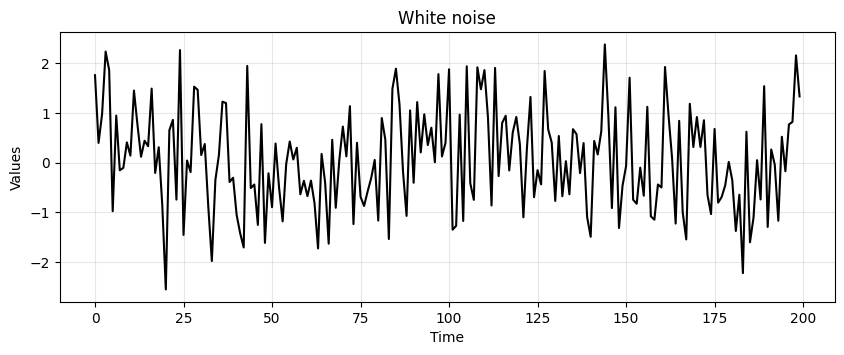

In [7]:
run_sequence_plot(time, stationary, title="White noise");

#### Time series with trend

- Consider the following data.

In [8]:
trend = (time * 2.75) + stationary #stationary is a white noise

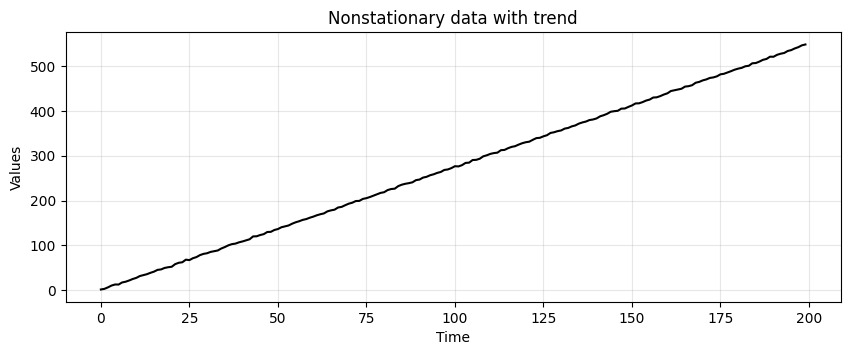

In [9]:
run_sequence_plot(time, trend, title="Nonstationary data with trend");

- Is this data stationary?

- No, the mean changes over time and violates condition #1.

#### Heteroscedastic time series

In [11]:
level_1 = np.random.normal(loc=0, scale=1.0, size = 100)
level_2 = np.random.normal(loc=0, scale=10.0, size = 100)
heteroscedasticity = np.append(level_1, level_2)

<Axes: title={'center': 'Level1'}, xlabel='Time', ylabel='Values'>

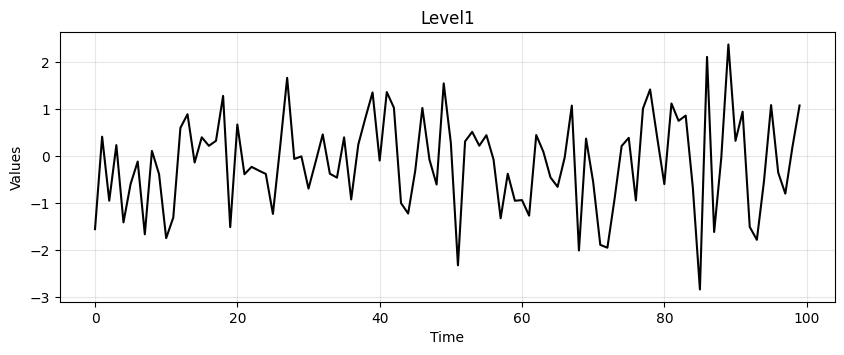

In [13]:
run_sequence_plot(time[:100], level_1 ,title='Level1' )

<Axes: title={'center': 'Level2'}, xlabel='Time', ylabel='Values'>

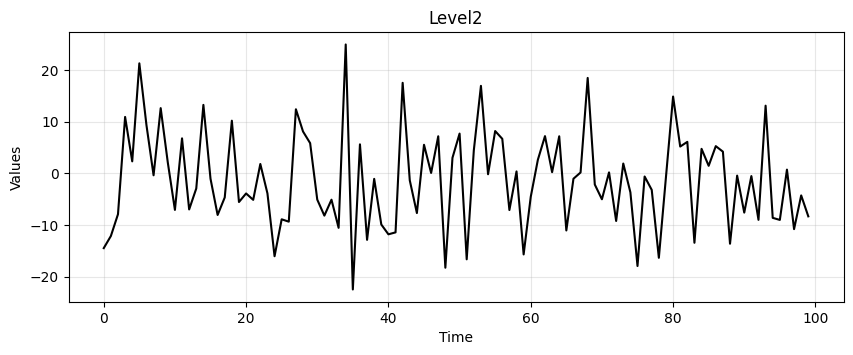

In [15]:
run_sequence_plot(time[:100], level_2 ,title='Level2' )

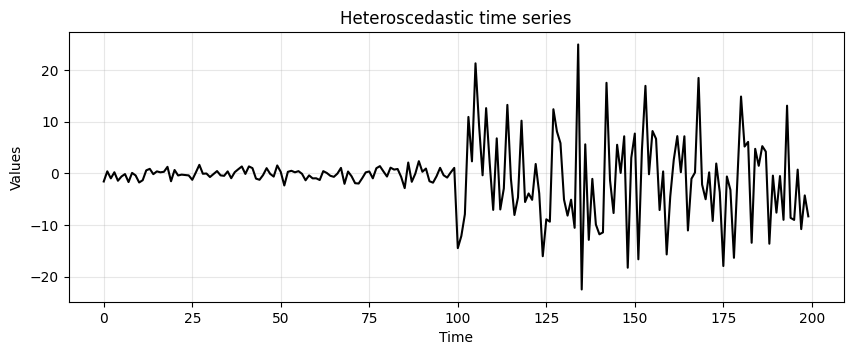

In [16]:
run_sequence_plot(time, heteroscedasticity, title="Heteroscedastic time series");

- Is this data stationary?

- No, the variance changes over time.

#### Time series with seasonality

In [17]:
seasonality = 20 + np.sin(2*np.pi*time/12)*20

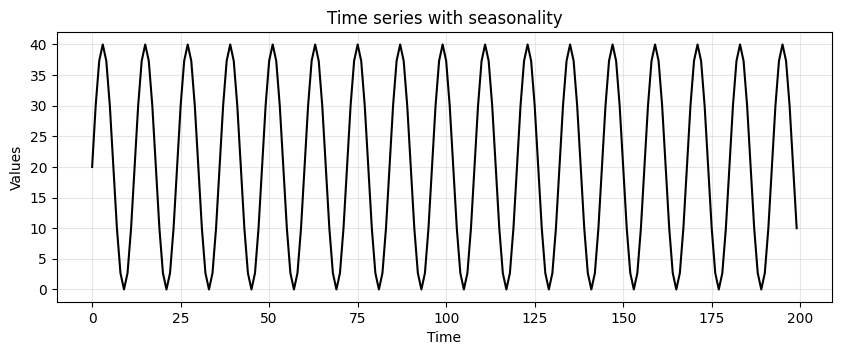

In [18]:
run_sequence_plot(time, seasonality, title="Time series with seasonality");

- Is this time series stationary?

- The mean of a periodic signal over a complete cycle always assumes the same value (`20` in our case).
- However, over an half-cycle or any period not equal to an integer multiple of the full cycle, the mean changes (is different from `20`).
- This violates condition #1.

<img src="https://github.com/FilippoMB/python-time-series-handbook/blob/main/notebooks/02/media/periodic_mean.png?raw=1" style="width: 80%; display: block; margin: auto;">

#### Time series with trend and seasonality

In [19]:
trend_seasonality = trend + seasonality + stationary

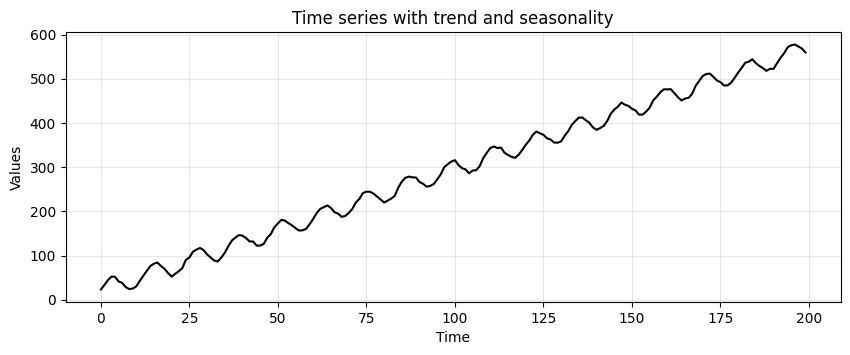

In [20]:
run_sequence_plot(time, trend_seasonality, title="Time series with trend and seasonality");

- Is this data stationary?

- No, the mean changes over time because of the trend AND there is a periodic component.

**📨 Take-away message**
- A time series obtained from a periodic function might be weakly stationary.
- The presence of periodic functions is not explicitly stated in the 3 conditions.
- Be careful when you determine weak stationarity based on periodic components.

---

## Detecting stationarity

Next, we will review practical techniques used to identify if a time series is stationary or not.

Specifically, we will cover:
1. Run-sequence plots
2. Summary statistics
3. Augmented Dickey-Fuller test [[Source](https://en.wikipedia.org/wiki/Augmented_Dickey%E2%80%93Fuller_test)]

### Run-Sequence Plots

- Run-sequence plots allows to visualize what's happening with the data.
- This should always be your starting point.
- Indeed, that is what we have been doing so far with our function `run_sequence_plot`.
- It often shows whether there is an underlying structure.
- Be on the lookout for trend, seasonality, and autocorrelation.

### Summary Statistics

- An easy way to check for constant mean and variance is to chop up the data into separate chunks.
- Then, one calculates statistics for each chunk, and compare them.
- Large deviations in either the mean or the variance among chunks might indicate that the time series is nonstationary.
- It's not a rigorous method but gives a good hint of whether the data is approximately stationary or not.

This is how a stationary time series looks like.

<img src="https://github.com/FilippoMB/python-time-series-handbook/blob/main/notebooks/02/media/stationary_chunk.png?raw=1" style="width: 45%; display: block; margin: auto;">

This is how a non-stationary time series looks like.

<img src="https://github.com/FilippoMB/python-time-series-handbook/blob/main/notebooks/02/media/nonstationary_chunk.png?raw=1" style="width: 45%; display: block; margin: auto;">

- Let's look at an example based on the `trend` time series that we created before.

In [21]:
# split data into 10 chunks
chunks = np.split(trend, indices_or_sections=10)

Summary statistics:

In [24]:
print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks, 1):
    print(f"{i}\t | {np.mean(chunk)}\t | {np.var(chunk)}")

Chunk	 | Mean		 | Variance
-----------------------------------
1	 | 26.69433459294563	 | 241.23013693801659
2	 | 81.18075035348672	 | 255.6170025954472
3	 | 135.72991694023145	 | 258.4677949873769
4	 | 190.77282897679217	 | 257.07996338150326
5	 | 246.5462092142165	 | 257.8231171685603
6	 | 301.62163039900116	 | 259.14881539904343
7	 | 356.1944984338708	 | 249.28242487500765
8	 | 411.08887790057105	 | 244.1112766883522
9	 | 466.1354557727262	 | 245.3711880113483
10	 | 520.99460234757	 | 275.1107031175936


- While the variance is relatively constant over time, the mean is clearly changing, which means this data is not stationary.
- We do expect some fluctuation in values.
- It's unlikely that mean and variance will be exactly the same in all chunk, but they should be close.

- To see this better, it's a good idea to plot the means and variances.
- If you want to be more precise, you could run a statistical test to determine if the difference in means or the difference in variances is statistically significant.

### Augmented Dickey-Fuller Test

- This is a statistical procedure to determine whether a time series is stationary or not.
- We will discuss more details about the test in the next lectures.
- For now, that's what we need to know:
    1. **Null hypothesis:** $H_0$: the series is nonstationary.
    2. **Alternative hypothesis:** $H_A$: the series is stationary.

- Like any statistical test you should set a significance level or threshold that determines whether you should accept or reject the null.
- The values $\alpha=0.05$ or $\alpha=0.01$, which yield a confidence of $95\%$ and $99\%$, respectively, are common choices.

Example: $p = 0.0001 \rightarrow$ reject $H_0 \rightarrow$ the time series is stationary

Example: $p = 0.43 \rightarrow$ fail to reject $H_0 \rightarrow$ the time series is non-stationary

- The ADF test might be inaccurate with small datasets or when heteroskedasticity is present.
- It is best to pair ADF with other techniques (run-sequence plots, summary statistics, histograms, etc..).

#### Stationary Data & ADF

- Let's see how to run this test in Python.

In [25]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(stationary)

- Let's see and comment the main outputs from the ADF test.

In [26]:
print(f"ADF: {adf:.2f}")

ADF: -13.56


- First, `adf` is the value of the test statistic.
- The more negative the value, the more confident we can be that the series is stationary.
- Here we see a negative value.
- That may not mean anything to you just yet but `pvalue` should.

In [27]:
print(f"p-value: {pvalue}")

p-value: 2.3001721380706884e-25


- The `pvalue` is interpreted like any p-value.
- The `pvalue` should be compared with the confidence levels (e.g., $\alpha=0.05$ or $\alpha=0.01$).
- Based on the comparison, we reject or fail to reject $H_0$.
- Here ``pvalue`` is very close to zero so we **reject** the $H_0$ in favor of $H_A$ and conclude that the time series is stationary.

In [28]:
print(f"nobs: {nobs}")

nobs: 199


- The variable `nobs` is simply the number of observations in the time series.

In [29]:
print(f"critical values: {critical_values}")

critical values: {'1%': np.float64(-3.4636447617687436), '5%': np.float64(-2.8761761179270766), '10%': np.float64(-2.57457158581854)}


- Finally, ``critical_values`` are the test statistic thresholds for common significant levels.
- Here we see a test statistic lower than -2.87 is sufficient to reject $H_0$ at a significance level of 5%.

- You may have noticed two outputs we didn't discuss.
- See [statsmodels docs](http://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) for a description of ``usedlag`` and ``icbest``.

#### ADF on time series with trend
- Next, we run the ADF test on the `trend` time series.

In [30]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(trend, regression='c')
print(f"ADF: {adf:.2f}")
print(f"p-value: {pvalue:.3f}")

ADF: 0.82
p-value: 0.992


- As expected, we fail to reject $H_0$ that the `trend` time series is nonstationary.

---

## Common transformations to achieve stationarity

- There are several ways to transform nonstationary time series data:

Transformation | Effect
:---|:---
Subtract trend | Constant mean
Apply log | Constant variance
Differencing | Remove autocorrelation
Seasonal differencing | Remove periodic component

- Sometimes you'll have to do multiple transformations on the same dataset.
- Note that this is just a small subset of the total possible ways to transform nonstationary time series.

### Stabilize variance with log transform

- This trick is useful when dealing with heteroskedastic data.
- The log squashes the parts of the time series where the variance is higher.
- In this way, the variance becomes more uniform.
- Let's plot again the heteroskedastic times series to remember how it looks.

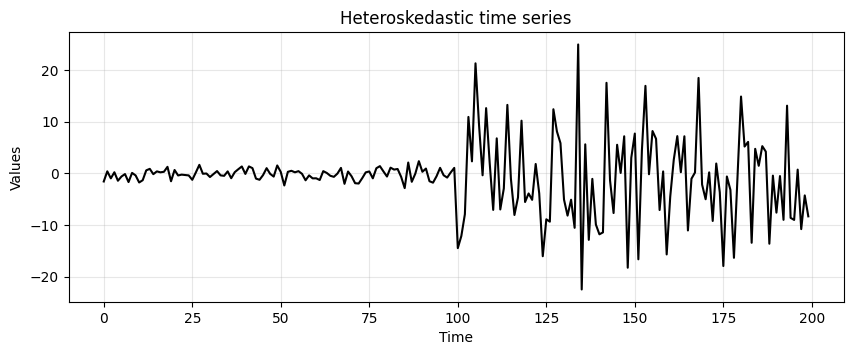

In [65]:
run_sequence_plot(time, heteroscedasticity, title="Heteroskedastic time series");

- Let's run the ADF test.

In [66]:
adf_b4, pvalue_b4, _, _, _, _ = adfuller(heteroscedasticity)
print(f"ADF: {adf_b4:.2f}")
print(f"p-value: {pvalue_b4:.3f}")

ADF: -15.14
p-value: 0.000


- ADF is saying we cannot reject $H_0$ in favor of the alternative (the time series is stationary).

- Let's now apply the log transformation.
- Before that, we subtract the minimum and add a small constant
- In this way we ensure that all values are positive before taking the log.

In [67]:
# Ensure all data are positive
new_hetero = heteroscedasticity - heteroscedasticity.min() + 1.0

# Apply the log
log_new_hetero = np.log(new_hetero)

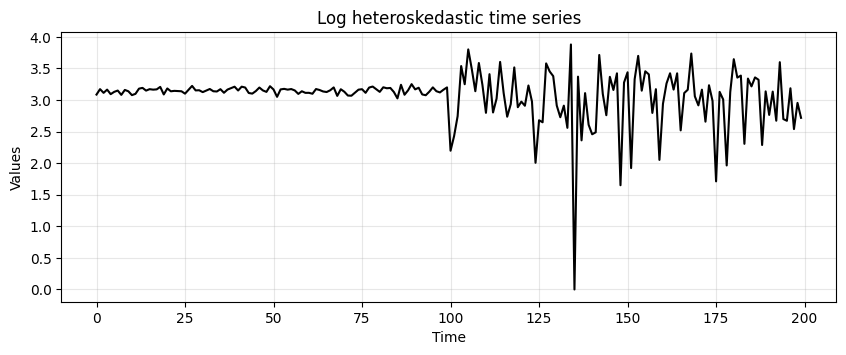

In [68]:
run_sequence_plot(time, log_new_hetero, title="Log heteroskedastic time series");

- Look at the values on the $y$ axis.
- Notice how the variance has collapsed to a large extent.

- Let's compute again the ADF test:

In [69]:
adf_log, pvalue_log, _, _, _, _ = adfuller(log_new_hetero)
print(f"ADF: {adf_log:.2f}")
print(f"p-value: {pvalue_log:.3f}")

ADF: -15.58
p-value: 0.000


- We now see that the p-value decreased quite a lot.
- We still cannot reject $H_0$ at confidence level $\alpha=0.01$, but we can at $\alpha=0.05$.

### Removing autocorrelation with differencing



#### Random walk

- The random walk is one of the most important **nonstationary** time series.
- It is defined as:

$$X(t) = X(t-1) + \epsilon_t$$

- where $\epsilon_t$ are called *innovations* and are iid, e.g., $\epsilon_t \sim \mathcal{N}(0,\sigma^2)$.

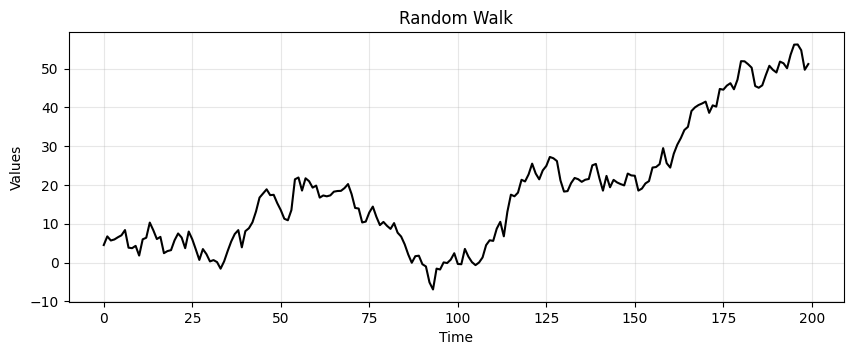

In [70]:
 #seed to start series
seed = 3.14

# Random Walk
rand_walk = np.empty_like(time, dtype='float')
for t in time:
    rand_walk[t] = seed + np.random.normal(loc=0, scale=2.5, size=1)[0]
    seed = rand_walk[t]
run_sequence_plot(time, rand_walk, title="Random Walk");

- We can transform `rand_walk` into stationary time series by applying differencing.
- This is done by subtracting a past value from the current value.

- We know that `rand_walk` was created with a lag of 1.
- So, a stationary time series can be obtained as:

$$\hat{X}(t) = X(t) - X(t-1)$$

In [71]:
difference = rand_walk[1:] - rand_walk[:-1]

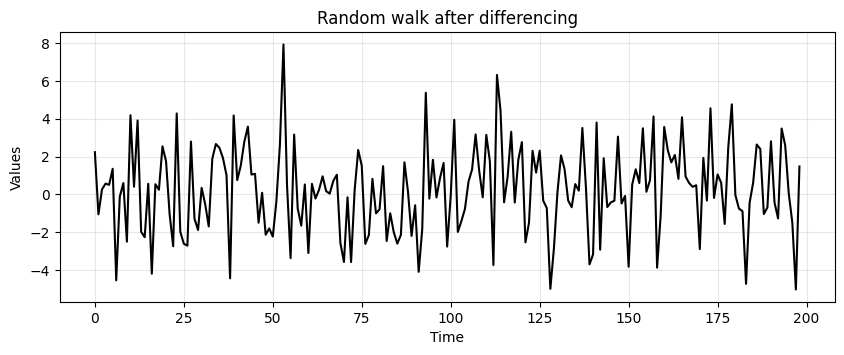

In [72]:
run_sequence_plot(time[:-1], difference, title="Random walk after differencing");

- Let's run ADF on the differenced data.

In [73]:
adf_after, pvalue_after, _, _, _, _ = adfuller(difference)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -13.57
p-value: 0.000


- Now it's stationary!

- Let's see another example.
- We create a small dataframe from 1-10 (linear and squared).

In [ ]:
df = pd.DataFrame([[x for x in range(1,11)], [x**2 for x in range(1,11)]]).T
df.columns = ['original', 'squared']
df

- Make stationary the first time series (``original``) so that mean and variance don't change for sub-windows.

In [ ]:
df.original.diff().to_frame("1st order difference")

```{note}
This is similar to taking a first-order derivative.
```

In [ ]:
df.squared.diff().diff().to_frame("2nd order difference")

- Notice that we need to differentiate twice on the exponential time series.
- Every time we do differencing we lose a bit of data.

- We can also try to make stationary the second time series (``squared``) with log.

In [ ]:
np.log(df.squared).to_frame("log")

- Works somewhat but certainly not as well as differencing.

- In general we do not know the optimal lag to perform differencing.
- How to determine the optimal order of differentiation will be covered later on.

### Seasonal differentiation

- Consider a time series with a seasonality of period $L$.
- There will be a strong correlation between $X(t)$ and $X(t+L)$.
- Seasonal differentiation can remove the seasonality and make the time series stationary:

$$\hat{X}(t) = X(t+L) - X(t)$$

- After seasonal differencing the time series will become $L$ steps shorter.
- Note that we can perform the standard differentiation in cascade to seasonal differentiation if we need to remove also the trend on top of the seasonality.
- Let's see this on the `trend_seasonality` time series.

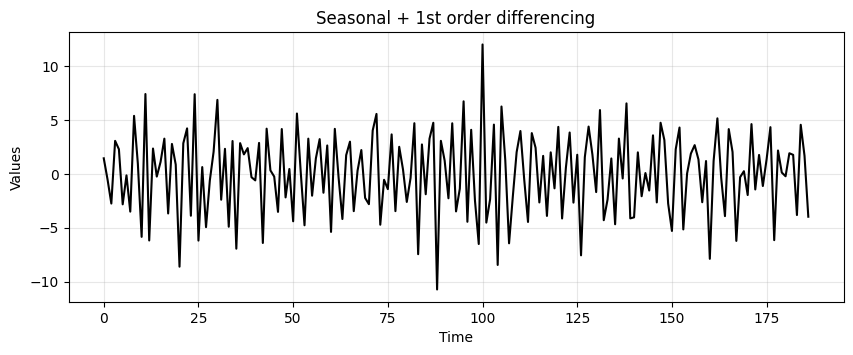

In [74]:
trend_seasonality_d12 = (trend_seasonality[:-12]
                         - trend_seasonality[12:]) # remove seasonality
trend_seasonality_d12_d1 = (trend_seasonality_d12[:-1]
                            - trend_seasonality_d12[1:]) # remove trend

# Plot the differenced time series
run_sequence_plot(time[:-13], trend_seasonality_d12_d1, title="Seasonal + 1st order differencing");

In [75]:
adf_after, pvalue_after, _, _, _, _ = adfuller(trend_seasonality_d12_d1)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -5.28
p-value: 0.000


---

## Summary

In this lecture we learned:
1. What does it mean for a time series to be stationary.
2. A set of notable stationary and nonstationary time series.
2. Common tools to identify stationarity.
3. Useful nonstationary-to-stationary transformations.

---